In [2]:

import pandas as pd
import numpy as np
import seaborn as sns
import ast
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib import cm

import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from torchinfo import summary
from torchmetrics import Accuracy
from torchvision import datasets
from torchvision.transforms import ToTensor
import torch.optim as optim


In [3]:
# Import the dataset

df = pd.read_csv('Randomized_data_with_single_coil_measurement_Nov_22.csv', parse_dates = True, index_col=0)  


In [3]:
# Create an empty DataFrame
concatenated_df = pd.DataFrame()


for i in range(1, 17):
    # isolating data for  each sensor
    df_s = df[['msdCoilCurrent_1(A)','msdCoilCurrent_2(A)','msdCoilCurrent_3(A)','msdCoilCurrent_4(A)',
                      'msdCoilCurrent_5(A)','msdCoilCurrent_6(A)','msdCoilCurrent_7(A)','msdCoilCurrent_8(A)', 
                      f'Sensor_{i}_dir_x', f'Sensor_{i}_dir_y', f'Sensor_{i}_dir_z', 
                      f'sensor_{i}_X [mT]', f'sensor_{i}_Y [mT]', f'sensor_{i}_Z [mT]']]
    
    # Reset index to remove duplicates and change the column names
    df_s = df_s.reset_index(drop=True)
    df_s.columns = ['msdCoilCurrent_1(A)','msdCoilCurrent_2(A)','msdCoilCurrent_3(A)','msdCoilCurrent_4(A)',
                      'msdCoilCurrent_5(A)','msdCoilCurrent_6(A)','msdCoilCurrent_7(A)','msdCoilCurrent_8(A)', 
                      'x', 'y','z', 
                      'U', 'V', 'W']
    # concatenating
    concatenated_df = pd.concat([concatenated_df, df_s],ignore_index=True)

In [4]:
# Save the concatenated DataFrame to a CSV file
concatenated_df.to_csv('Processed_Randomized_data_for_msdCurrent_Dec_13.csv', index=True)  # index=True to include datetime index

In [ ]:
df

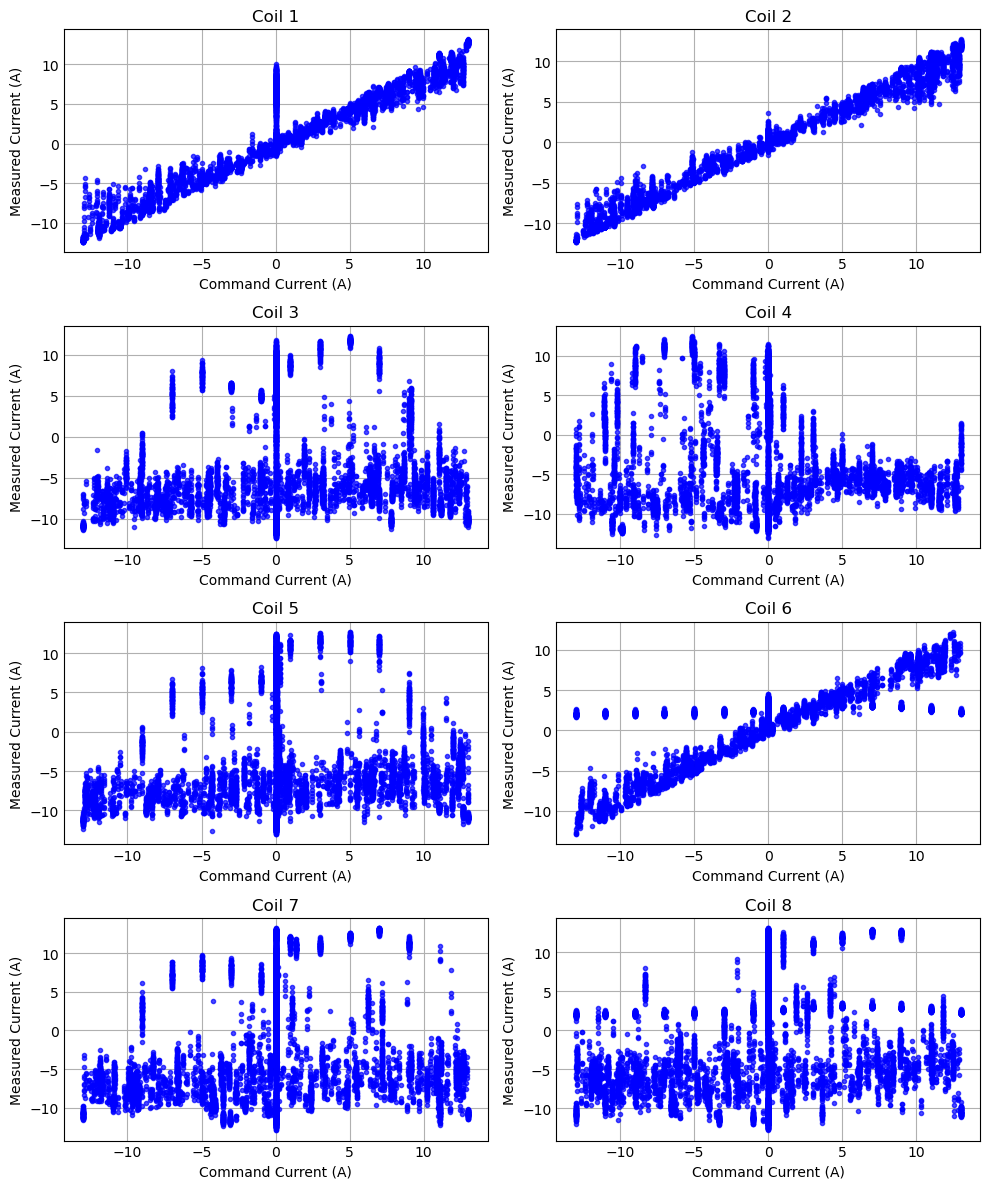

In [92]:

# Define the columns to compare
comparisons = [
    ('cmdCoilCurrent_1(A)', 'msdCoilCurrent_1(A)'),
    ('cmdCoilCurrent_2(A)', 'msdCoilCurrent_2(A)'),
    ('cmdCoilCurrent_3(A)', 'msdCoilCurrent_3(A)'),
    ('cmdCoilCurrent_4(A)', 'msdCoilCurrent_4(A)'),
    ('cmdCoilCurrent_5(A)', 'msdCoilCurrent_5(A)'),
    ('cmdCoilCurrent_6(A)', 'msdCoilCurrent_6(A)'),
    ('cmdCoilCurrent_7(A)', 'msdCoilCurrent_7(A)'),
    ('cmdCoilCurrent_8(A)', 'msdCoilCurrent_8(A)')
]

# Set up the subplot grid (4 rows, 2 columns)
fig, axes = plt.subplots(4, 2, figsize=(10, 12))

# Flatten the axes array for easy indexing
axes = axes.flatten()

# Loop through comparisons and create scatter plots
for i, (col_x, col_y) in enumerate(comparisons):
    ax = axes[i]
    ax.scatter(df[col_x], df[col_y], color='blue', marker='.', alpha=0.7)
    ax.set_xlabel("Command Current (A)")
    ax.set_ylabel("Measured Current (A)")
    ax.set_title(f'Coil {i+1}')
    ax.grid(True)

# Adjust layout
plt.tight_layout()
plt.show()

it is difficult to separate the effects of cross magnetization and current controller inaccuracy.
Further investigation is needed to dermine if this is due to the cross magnetizatoin effect or faulty current controller.


In [93]:
# Get cpu or gpu for training.
device = "cuda" if torch.cuda.is_available() else "cpu"

# loading best_cmd_model
model = torch.load("../../Model_tunning/best_msdCurrent_model.pth", map_location=torch.device('cpu'))

C:\Users\Gediy\AppData\Local\Temp\ipykernel_17044\4284102027.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load("../../Model_tunning/best_msdCurrent_mode

In [79]:
# importing test dataset
df1_clean = pd.read_csv('../../superposition_test/test1_measured.csv', parse_dates = True, index_col=0)  #  table data
df2_clean = pd.read_csv('../../superposition_test/test2_measured.csv', parse_dates = True, index_col=0)  #  table data
df3_clean = pd.read_csv('../../superposition_test/test3_measured.csv', parse_dates = True, index_col=0)  #  table data

In [80]:
def Quiver_plot(grid_pts,field_predicted):

    plt.style.use('_mpl-gallery')

    # Make data
    
    x = grid_pts[:,0]
    y = grid_pts[:,1]
    z = grid_pts[:,2]

    U = field_predicted[:,0]

    V = field_predicted[:,1]

    W = field_predicted[:,2]

    # Compute the magnitude of the vectors
    magnitude = np.sqrt(U**2 + V**2 + W**2)
    
    print(np.max(magnitude))

    # Normalize the magnitudes to the range [0, 1]
    norm = Normalize(vmin=magnitude.min(), vmax=magnitude.max())

    # Create a colormap object
    colormap = cm.winter_r # You can choose other colormaps like 'plasma', 'inferno', etc.


    # Plot
    # Create a figure with custom size
    fig = plt.figure(figsize=(12, 8))  # Set figure size
    ax = fig.add_subplot(111, projection='3d')

    plot = ax.quiver(x, y, z, U, V, W, length=0.002, normalize= False, color=colormap(norm(magnitude)))

    # Add a colorbar to show the mapping of magnitudes to colors
    mappable = cm.ScalarMappable(norm=norm, cmap=colormap)
    cbar = plt.colorbar(mappable, ax=ax)
    cbar.set_label('Magnitude [mT]')

    ax.set(xticklabels=[],
        yticklabels=[],
        zticklabels=[],
        xlabel = ('X axis [m]'),
        ylabel = ('Y axis [m]'),
        zlabel = ('Z axis [m]'),
        title = ('Magnetic flux [mT]'))

    plt.show()

In [84]:
def Analyze_model(data):
        x = data[['Sensor_1_dir_x','Sensor_2_dir_x','Sensor_3_dir_x','Sensor_4_dir_x',
                'Sensor_5_dir_x','Sensor_6_dir_x','Sensor_7_dir_x','Sensor_8_dir_x',
                'Sensor_9_dir_x','Sensor_10_dir_x','Sensor_11_dir_x','Sensor_12_dir_x',
                'Sensor_13_dir_x','Sensor_14_dir_x','Sensor_15_dir_x','Sensor_16_dir_x']].values.reshape(-1, 1)

        y = data[['Sensor_1_dir_y','Sensor_2_dir_y','Sensor_3_dir_y','Sensor_4_dir_y',
                'Sensor_5_dir_y','Sensor_6_dir_y','Sensor_7_dir_y','Sensor_8_dir_y',
                'Sensor_9_dir_y','Sensor_10_dir_y','Sensor_11_dir_y','Sensor_12_dir_y',
                'Sensor_13_dir_y','Sensor_14_dir_y','Sensor_15_dir_y','Sensor_16_dir_y']].values.reshape(-1, 1)

        z = data[['Sensor_1_dir_z','Sensor_2_dir_z','Sensor_3_dir_z','Sensor_4_dir_z',
                'Sensor_5_dir_z','Sensor_6_dir_z','Sensor_7_dir_z','Sensor_8_dir_z',
                'Sensor_9_dir_z','Sensor_10_dir_z','Sensor_11_dir_z','Sensor_12_dir_z',
                'Sensor_13_dir_z','Sensor_14_dir_z','Sensor_15_dir_z','Sensor_16_dir_z']].values.reshape(-1, 1)

        grid_pts = np.hstack((x,y,z))
        #grid_pts = np.vstack((grid_pts))

        cmdCurrent = data[["msdCoilCurrent_1(A)","msdCoilCurrent_2(A)","msdCoilCurrent_3(A)","msdCoilCurrent_4(A)",
                           "msdCoilCurrent_5(A)","msdCoilCurrent_6(A)", "msdCoilCurrent_7(A)", "msdCoilCurrent_8(A)"]].values
        
        cmdCurrent = np.repeat(cmdCurrent, 16, axis=0).reshape(-1, cmdCurrent.shape[1]) # repeat the cmdCurrent for each row and reshape it to match the grid pts
        
        model_input = np.hstack((cmdCurrent,grid_pts)) # combine cmdCurrent with grid pts to form inpput vector for our model
        
        model_input = torch.tensor(model_input, dtype=torch.float32)

        

        
        prediction = model(model_input)
                
                
        Quiver_plot(grid_pts,prediction.detach().numpy()) 

        
        
        U_measured = data[['sensor_1_X [mT]','sensor_2_X [mT]','sensor_3_X [mT]','sensor_4_X [mT]',
                    'sensor_5_X [mT]','sensor_6_X [mT]','sensor_7_X [mT]','sensor_8_X [mT]',
                    'sensor_9_X [mT]','sensor_10_X [mT]','sensor_11_X [mT]','sensor_12_X [mT]',
                    'sensor_13_X [mT]','sensor_14_X [mT]','sensor_15_X [mT]','sensor_16_X [mT]']].values.reshape(-1, 1)

        V_measured = data[['sensor_1_Y [mT]','sensor_2_Y [mT]','sensor_3_Y [mT]','sensor_4_Y [mT]',
                        'sensor_5_Y [mT]','sensor_6_Y [mT]','sensor_7_Y [mT]','sensor_8_Y [mT]',
                        'sensor_9_Y [mT]','sensor_10_Y [mT]','sensor_11_Y [mT]','sensor_12_Y [mT]',
                        'sensor_13_Y [mT]','sensor_14_Y [mT]','sensor_15_Y [mT]','sensor_16_Y [mT]',]].values.reshape(-1, 1)


        W_measured = data[['sensor_1_Z [mT]','sensor_2_Z [mT]','sensor_3_Z [mT]','sensor_4_Z [mT]',
                        'sensor_5_Z [mT]','sensor_6_Z [mT]','sensor_7_Z [mT]','sensor_8_Z [mT]',
                        'sensor_9_Z [mT]','sensor_10_Z [mT]','sensor_11_Z [mT]','sensor_12_Z [mT]',
                        'sensor_13_Z [mT]','sensor_14_Z [mT]','sensor_15_Z [mT]','sensor_16_Z [mT]',]].values.reshape(-1, 1)
        
        
        B_measured = torch.tensor(np.hstack([U_measured,V_measured,W_measured]), dtype=torch.float32)
        
        
        def metrics_fn(outputs, labels):
            RMSE = torch.sqrt(torch.mean((labels-outputs)**2,dim= 0, keepdim=False))
            
            
            MAE = torch.mean(torch.abs(labels-outputs),dim= 0, keepdim=False)
            
            labels = torch.where(labels == 0, torch.tensor(1e-6), labels) # to avoid division by zero
            
            percentage_error = (labels-outputs)/labels            
            MAEP = torch.mean(torch.abs(percentage_error),dim= 0, keepdim=False)
                 
            output_norm = torch.norm(outputs, p=2, dim=1, keepdim=False, out=None)
            labels_norm = torch.norm(labels, p=2, dim=1, keepdim=False, out=None)
            
            RMSE_norm = torch.sqrt(torch.mean((labels_norm-output_norm)**2))
                   
            MAE_norm = torch.mean(torch.abs(labels_norm-output_norm),dim= 0, keepdim=False) # mean absolute error 
            
            percentage_error_norm = (labels_norm - output_norm)/labels_norm
            MAEP_norm = torch.mean(torch.abs(percentage_error_norm)) # mean absolute error
            
            
            labels_norm = torch.where(labels_norm== 0, torch.tensor(1e-6), labels_norm) # to avoid division by zero
            output_norm = torch.where(output_norm == 0, torch.tensor(1e-6), output_norm) # to avoid division by zero
            
            
            phi_measured = torch.arcsin(labels[:,2]/labels_norm) # orientation of the magnetic field relative to the horizontal plane
            phi1 = torch.arcsin(outputs[:,2]/output_norm)
            
            label_h_norm = torch.sqrt(labels[:,0]**2 + labels[:,1]**2)
            output_h_norm = torch.sqrt(outputs[:,0]**2 + outputs[:,1]**2)
            
            label_h_norm = torch.where(label_h_norm == 0, torch.tensor(1e-6), label_h_norm) # to avoid division by zero
            output_h_norm = torch.where(output_h_norm == 0, torch.tensor(1e-6), output_h_norm) # to avoid division by zero

            theta_measured = torch.arcsin(labels[:,1]/label_h_norm) # orientation of the magnetic field relative to the x-axis
            theta1 = torch.arcsin(outputs[:,1]/output_h_norm)
            
            phi_error = phi_measured - phi1
            theta_error = theta_measured - theta1
            
                    # mean absolute error for the orientaion
            phi_abs_error = torch.mean(np.abs(phi_error))
            theta_abs_error = torch.mean(np.abs(theta_error))
            
            
            return RMSE,RMSE_norm, MAE, MAE_norm, MAEP, MAEP_norm, phi_abs_error, theta_abs_error
        
        
        RMSE, RMSE_norm,MAE, MAE_norm, MAEP, MAEP_norm, phi_abs_error, theta_abs_error = metrics_fn(prediction.detach(),B_measured)
        
        
        print(f"RMSE: {RMSE}")
        print(f"RMSE_norm: {RMSE_norm}")
        print(f"MAE: {MAE}")
        print(f"MAE_norm: {MAE_norm}")
        print(f"MAEP: {MAEP}")
        print(f"MAEP_norm: {MAEP_norm}")
        print(f"phi_MAE: {phi_abs_error} and in degrees: {np.degrees(phi_abs_error.detach().numpy())}")
        print(f"theta_MAE: {theta_abs_error} and degrees: {np.degrees(theta_abs_error.detach().numpy())}")

31.01644


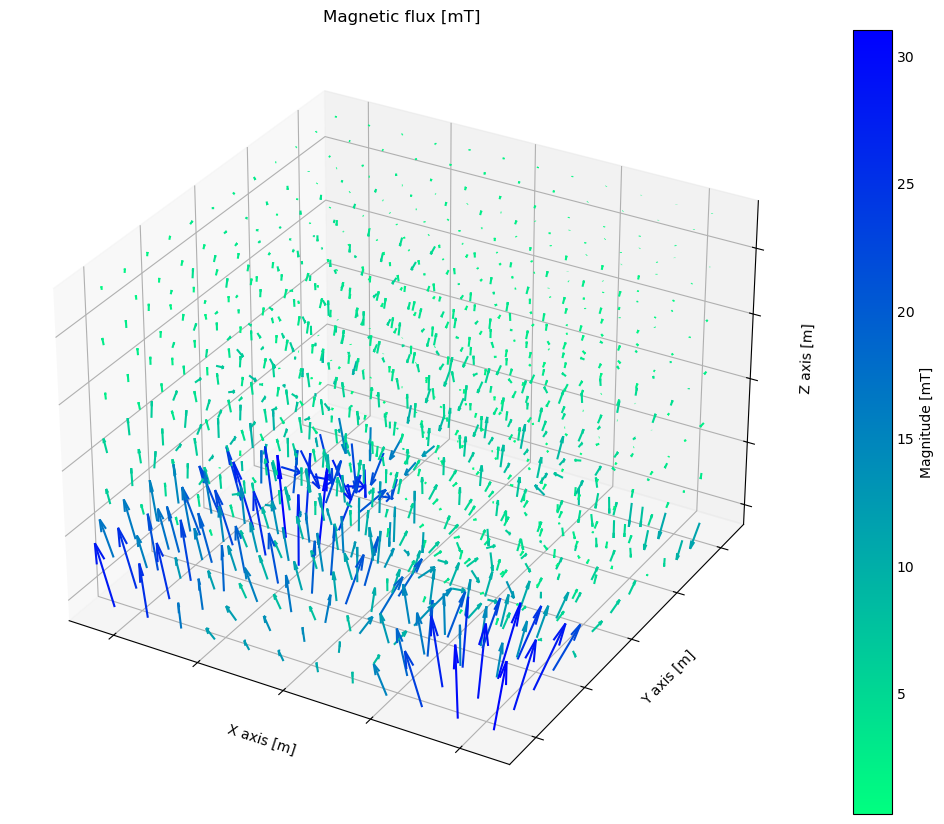

RMSE: tensor([3.8185, 4.7806, 7.8413])
RMSE_norm: 5.113675117492676
MAE: tensor([2.7684, 3.4959, 5.6247])
MAE_norm: 3.774081230163574
MAEP: tensor([ 3.7129, 28.9048,  0.9634])
MAEP_norm: 0.446010559797287
phi_MAE: 0.8779415488243103 and in degrees: 50.30234146118164
theta_MAE: 0.9420145153999329 and degrees: 53.973453521728516


In [94]:
Analyze_model(df1_clean)

54.32729


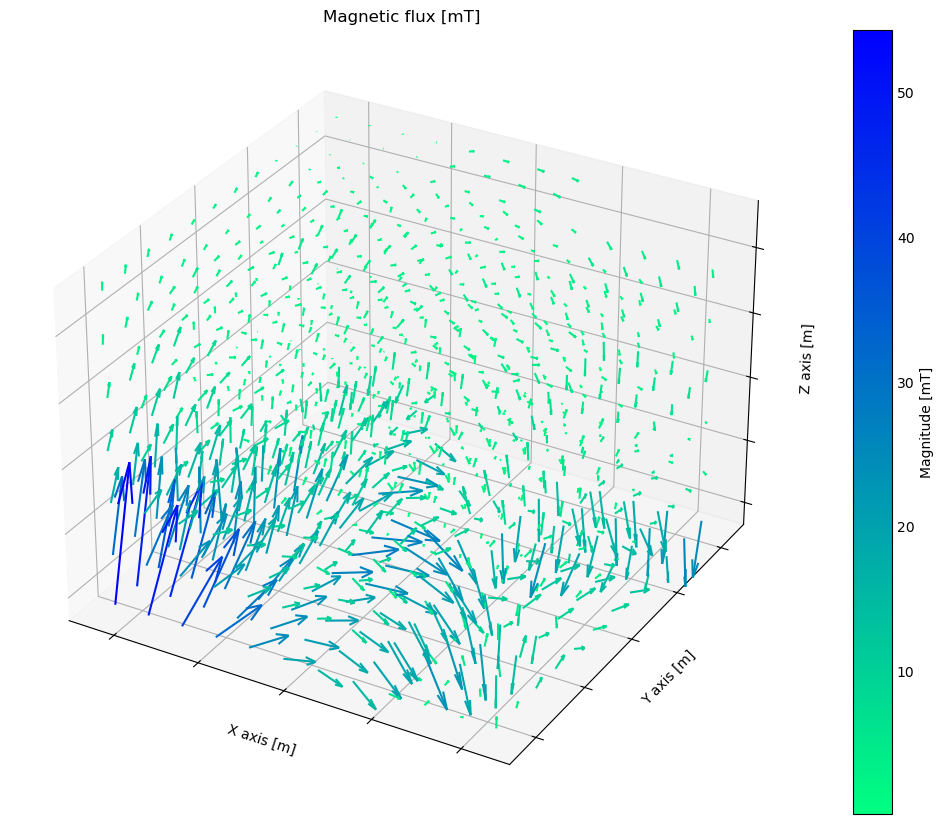

RMSE: tensor([5.6957, 5.8839, 9.5365])
RMSE_norm: 8.13068675994873
MAE: tensor([3.9734, 3.8687, 5.9411])
MAE_norm: 4.911480903625488
MAEP: tensor([1.1699, 7.2294, 3.5759])
MAEP_norm: 0.47809651494026184
phi_MAE: 0.7169974446296692 and in degrees: 41.08092498779297
theta_MAE: 0.9773830771446228 and degrees: 55.99992370605469


In [95]:
Analyze_model(df2_clean)

42.017223


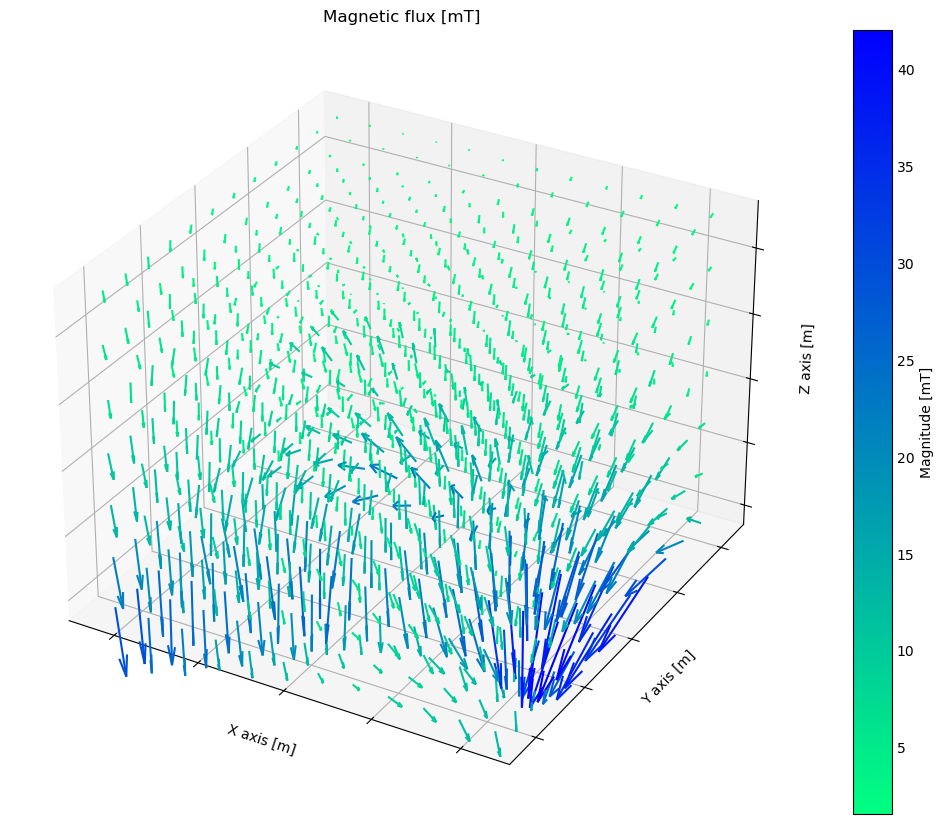

RMSE: tensor([4.1771, 7.3499, 9.8767])
RMSE_norm: 8.158697128295898
MAE: tensor([2.3917, 4.8794, 6.2442])
MAE_norm: 4.484920978546143
MAEP: tensor([ 4.8192,  2.1213, 10.6810])
MAEP_norm: 0.40446585416793823
phi_MAE: 0.6094403266906738 and in degrees: 34.918357849121094
theta_MAE: 0.7886974215507507 and degrees: 45.189029693603516


In [96]:
Analyze_model(df3_clean)